# Image Classification of Selected Threatened/Endangered relevant to Singapore, with training images sourced from broader Southeast Asia using Neural Networks

### how the hierarchy works:

#### taxon id -- conservation status -- species -- scientific name -- family -- order -- class

43364 CR sunda pangolin -- manis javanica -- manidae -- pholidota (keratin scales) -- mammal




45982 CR red giant flying squirrel -- petaurista petaurista -- sciuridae -- rodentia (rodents) -- mammal




44172 CR east asian/malayan porcupine -- hystrix brachyura -- hystricidae -- rodentia (rodents) -- mammal




922738 CR mainland leopard cat -- prionailurus bengalensis -- felidae -- carnivora -- mammal



41602 CR small-toothed palm civet -- arctogalidia trivirgata -- viverridae -- carnivora -- mammal

41625 CR masked palm civet -- paguma larvata -- viverridae -- carnivora -- mammal

41613 CR large indian civet -- viverra zibetha -- viverridae -- carnivora -- mammal



1638835 CR asian small-clawed otter -- lutra cinera -- mustelidae -- carnivora -- mammal

1638842 EN smooth-coated otter -- lutra perspicillata -- mustelidae -- carnivora -- mammal

https://www.nparks.gov.sg/nature/species-list/terrestrial-mammals
3rd edition of the Singapore Red Data Book (RDB3).

#### focus:
##### identifying critically endangered species in Singapore, with focus on the Sunda Pangolin, the Raffles' Banded Langur, & the Leopard Cat

##### input tensors: 100 images of birds, monkeys, cats, & anteaters
##### target tensors: 100 images classified into its animal type, sub-animal type, & species


#### Imports & Configurations 

In [1]:
# import necessary libraries/dependencies 
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import PIL
from PIL import Image, ImageOps
from io import BytesIO
# import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import pathlib
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
# # checking if query filters relevant data
# # sunda pangolin
# test_url1 = "https://api.inaturalist.org/v2/observations?taxon_id=43364&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data1 = requests.get(test_url1)
# data1 = test_data1.json()
# print("Sunda Pangolin Status Code, Total Results:", test_data1.status_code, data1["total_results"])

# # red giant flying squirrel
# test_url4 = "https://api.inaturalist.org/v2/observations?taxon_id=45982&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data4 = requests.get(test_url4)
# data4 = test_data4.json()
# print("Red Giant Flying Squirrel Status Code, Total Results:", test_data4.status_code, data4["total_results"])

# # east asian/malayan porcupine
# test_url7 = "https://api.inaturalist.org/v2/observations?taxon_id=44172&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data7 = requests.get(test_url7)
# data7 = test_data7.json()
# print("East Asian/Malayan Porcupine Status Code, Total Results:", test_data7.status_code, data7["total_results"])

# # mainland leopard cat
# test_url8 = "https://api.inaturalist.org/v2/observations?taxon_id=922738&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data8 = requests.get(test_url8)
# data8 = test_data8.json()
# print("Mainland Leopard Cat Status Code, Total Results:", test_data8.status_code, data8["total_results"])

# # small-toothed palm civet
# test_url9 = "https://api.inaturalist.org/v2/observations?taxon_id=41602&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data9 = requests.get(test_url9)
# data9 = test_data9.json()
# print("Small-toothed Palm Civet Status Code, Total Results:", test_data9.status_code, data9["total_results"])

# # masked palm civet
# test_url10 = "https://api.inaturalist.org/v2/observations?taxon_id=41625&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data10 = requests.get(test_url10)
# data10 = test_data10.json()
# print("Masked Palm Civet Status Code, Total Results:", test_data10.status_code, data10["total_results"])

# # large indian civet
# test_url12 = "https://api.inaturalist.org/v2/observations?taxon_id=41613&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data12 = requests.get(test_url12)
# data12 = test_data12.json()
# print("Large Indian Civet Status Code, Total Results:", test_data12.status_code, data12["total_results"])

# # asian small-clawed otter
# test_url13 = "https://api.inaturalist.org/v2/observations?taxon_id=1638835&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data13 = requests.get(test_url13)
# data13 = test_data13.json()
# print("Asian Small-clawed Otter Status Code, Total Results:", test_data13.status_code, data13["total_results"])

# # smooth-coated otter
# test_url14 = "https://api.inaturalist.org/v2/observations?taxon_id=1638842&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data14 = requests.get(test_url14)
# data14 = test_data14.json()
# print("Smooth-coated Otter Status Code, Total Results:", test_data14.status_code, data14["total_results"])

#### since some species have too few images to work with due to restrictions with the area (species not spotted in Singapore/too few sightings), change project to focus on selected mammals from singapore, but are spotted elsewhere (SEA)

species selection --> based on Singapore's conservation relevance

image dataset --> iNaturalist observations from a wider range of area (geographic)

model objective --> distinguish select mammal species

one limitation may be the background (area in which animal is spotted); distribution/domain difference

since excluded the red-cheeked flying squirrel, the horsfield's flying squirrel, the shew-faced ground squirrel, the brown spiny rat, & the malay civet as the available observations on iNaturalist is not enough for eventually training the model

## Prepare ML Model Skeleton

In [54]:
# list of dictionaries for the species
# taxon id -- conservation status -- species -- scientific name -- family -- order

species_list = [
                    {
                        "species_name": "sunda pangolin",
                        "scientific_name": "manis javanica",
                        "animal_family": "manidae",
                        "animal_order": "pholidota",
                        "taxon_id": 43364,
                        "conservation_status": "CR",
                        "usable_count": 108
                    },
                    {
                        "species_name": "red giant flying squirrel",
                        "scientific_name": "petaurista petaurista",
                        "animal_family": "sciuridae",
                        "animal_order": "rodentia",
                        "taxon_id": 45982,
                        "conservation_status": "CR",
                        "usable_count": 39
                    },
                    {
                        "species_name": "east asian/malayan porcupine",
                        "scientific_name": "hystrix brachyura",
                        "animal_family": "hystricidae",
                        "animal_order": "rodentia",
                        "taxon_id": 44172,
                        "conservation_status": "CR",
                        "usable_count": 422
                    },
                    {
                        "species_name": "mainland leopard cat",
                        "scientific_name": "prionailurus bengalensis",
                        "animal_family": "felidae",
                        "animal_order": "carnivora",
                        "taxon_id": 922738,
                        "conservation_status": "CR",
                        "usable_count": 156 
                    },
                    {
                        "species_name": "small-tooth palm civet",
                        "scientific_name": "arctogalidia trivirgata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41602,
                        "conservation_status": "CR",
                        "usable_count": 82  
                    },
                    {
                        "species_name": "masked palm civet",
                        "scientific_name": "paguma larvata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41625,
                        "conservation_status": "CR",
                        "usable_count": 80  
                    },
                    {
                        "species_name": "large indian civet",
                        "scientific_name": "viverra zibetha",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41613,
                        "conservation_status": "CR",
                        "usable_count": 40  
                    },
                    {
                        "species_name": "asian small-clawed otter",
                        "scientific_name": "lutra cinera",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638835,
                        "conservation_status": "CR",
                        "usable_count": 90  
                    },
                    {
                        "species_name": "smooth-coated otter",
                        "scientific_name": "lutra perspicillata",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638842,
                        "conservation_status": "EN",
                        "usable_count": 1835  
                    }
                ]

for animal in species_list:
    print(animal["species_name"], animal["usable_count"])

sunda pangolin 108
red giant flying squirrel 39
east asian/malayan porcupine 422
mainland leopard cat 156
small-tooth palm civet 82
masked palm civet 80
large indian civet 40
asian small-clawed otter 90
smooth-coated otter 1835


#### We will now test the above with 3 observations

In [55]:
# resize & convert image to 80 x 80, rgb
def resize_photo(images):
    images = images.convert("RGB")
    target_size = (80, 80)

    padded_imgs = ImageOps.pad(images, 
                              target_size, 
                              color = "white", 
                              centering = (0.5, 0.5))

    return padded_imgs

In [56]:
# convert images to arrays
def img_to_arr(padded_imgs):
    imgs_arr = np.array(padded_imgs)

    print(imgs_arr.shape)

    return imgs_arr

In [57]:
# normalise images to [0, 1]
def normal_img(imgs_arr):
    imgs_arr = imgs_arr.astype("float32")
    imgs_arr /= 255.0

    return imgs_arr

In [58]:
# flatten 3D tensor into a 1D tensor
def flatten_arr(imgs_arr):
    flattened_arrs = imgs_arr.flatten()

    return flattened_arrs

In [59]:
# API request with dict key
def req_api(animal):
    page_index = 1 # first page is 1, not 0
    collected_obs = [] # for collecting observations
    max_obs = 100 # max. number of observations to collect
    
    url = f"https://api.inaturalist.org/v2/observations?place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"

    # while the no. of collected observations is lesser than delcared max.
    while len(collected_obs) < max_obs:
        query_params = {"taxon_id": animal["taxon_id"], "page": page_index} 
        
        # GET request to URL
        response = requests.get(url, params = query_params, timeout = 30)
        data = response.json()
        
        page_results = data["results"]

        if not page_results: # no more available observations on page
            break

        collected_obs += page_results # append observation (results) into empty list

        print("Page Number:", page_index,
             "| Retrieved:", len(page_results),
             "| Total Observations Collected:", len(collected_obs)
             )
        
        page_index += 1 # go to the next page

    trim_obs = collected_obs[:max_obs] # trim total no. of observations collected to previously set max.

    print(
        "Animal:", animal["species_name"],
        "| Final Observations:", len(trim_obs)
    )
    return trim_obs

# tag a number to an animal order
int_to_order = {
    0: "pholidota",
    1: "rodentia",
    2: "carnivora"
}

# tag an animal order to the numbers in int_to_order
order_to_int = {
    v: k for k, v in int_to_order.items()
}

# empty lists for converting animal orders to int
x_order = []
y_order = []

for animal in species_list:
    animal_info = req_api(animal)
    observations = animal_info

    animal_order = animal["animal_order"]
    order_int = order_to_int[animal_order]

    print(
        "\nProcessing:", animal["species_name"],
        "| Images:", len(observations),
        "| Order:", order_int
    )
    
    # display & preprocessing images
    for observation in observations:
        if not observation["photos"]: # photo from each observation
            continue

        photo_info = observation["photos"][0]
    
        if "url" not in photo_info:
            continue

        # first resizing of images
        new_url = photo_info["url"].replace("square", "medium")

        try:
            # download image
            img_response = requests.get(new_url, timeout = 30)

            if img_response.status_code != 200:
                continue

            images = Image.open(BytesIO(img_response.content)) # load images
            
            rs_observation = resize_photo(images)
            obs_arr = img_to_arr(rs_observation)
            normalised = normal_img(obs_arr)
            flat = flatten_arr(normalised)
    
            if flat.shape != (19200, ):
                continue
            
            x_order.append(flat) # append flattened vector into x_order
            y_order.append(order_int) # append order classification into y_order

        except Exception as e:
            print("Skipped Image:", e)

# convert lists to NumPy arrays after collection of observation's finished
x_order_arr = np.array(x_order, dtype = "float32")
y_order_arr = np.array(y_order, dtype = "int32")

print("\nFinal Order Dataset")
print("X shape:", x_order_arr.shape)
print("Y shape:", y_order_arr.shape)

print(
    "Pholidota:", np.sum(y_order_arr == 0),
    "Rodentia:", np.sum(y_order_arr == 1),
    "Carnivora:", np.sum(y_order_arr == 2)
)

Page Number: 1 | Retrieved: 30 | Total Observations Collected: 30
Page Number: 2 | Retrieved: 30 | Total Observations Collected: 60
Page Number: 3 | Retrieved: 30 | Total Observations Collected: 90
Page Number: 4 | Retrieved: 18 | Total Observations Collected: 108
Animal: sunda pangolin | Final Observations: 100

Processing: sunda pangolin | Images: 100 | Order: 0
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 

In [60]:
# save numpy arrays as files onto computer
# train & evaluate the model on a fixed snapshot of the dataset
np.save("x_order_arr.npy", x_order_arr)
np.save("y_order_arr.npy", y_order_arr)

In [ ]:
# reload images 
x_order_arr = np.load("x_order_arr.npy")
y_order_arr = np.load("y_order_arr.npy")

### Training / Validation / Test Split

Total images used: 731 

- 70% training --> ~511 images
- 15% validation --> ~110 images
- 15% test --> ~110 images

Sampling Technique: Stratify()
- ensure that the distribution of samples across different classes/categories remains representative of the population
    - samples are randomly selected from each group in proportion to their representation in the population ==> reduces the potential for bias in the analysis
- maintains the proportion of different classes 

In [64]:
# splitting dataset for training / testing

x_train, x_temp, y_train, y_temp = train_test_split(x_order_arr, 
                                                    y_order_arr, 
                                                    test_size = 0.3, 
                                                    stratify = y_order_arr)

x_val, x_test, y_val, y_test = train_test_split(x_temp, 
                                                y_temp, 
                                                test_size = 0.5, 
                                                stratify = y_temp)

In [68]:
# no. of samples in each set
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(511, 19200)
(110, 19200)
(110, 19200)


In [75]:
# verify split
values, counts = np.unique(y_train, return_counts = True)
frequencies = dict(zip(values, counts))
values2, counts2 = np.unique(y_val, return_counts = True)
frequencies2 = dict(zip(values2, counts2))
values3, counts3 = np.unique(y_test, return_counts = True)
frequencies3 = dict(zip(values3, counts3))

print(frequencies)
print(frequencies2)
print(frequencies3)

{np.int32(0): np.int64(69), np.int32(1): np.int64(98), np.int32(2): np.int64(344)}
{np.int32(0): np.int64(15), np.int32(1): np.int64(21), np.int32(2): np.int64(74)}
{np.int32(0): np.int64(15), np.int32(1): np.int64(21), np.int32(2): np.int64(74)}


In [76]:
# estimate class weights (dataset is unbalanced)
data_balance = compute_class_weight(class_weight = "balanced", classes = np.unique(y_train), y = y_train)
print(data_balance)

[2.46859903 1.73809524 0.49515504]


In [77]:
classes = np.unique(y_train)

db_results = {int(k): float(v) for k, v in zip(classes, data_balance)}
print(db_results)

{0: 2.468599033816425, 1: 1.7380952380952381, 2: 0.4951550387596899}


### Model with Dropout(0.1)

In [78]:
# new model but changed dropout
# ML model
f_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.1),
    layers.Dense(3, activation = "softmax")
])

# compile model
f_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

f_model_hist = f_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results
                )

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.7615 - sparse_categorical_accuracy: 0.3601 - val_loss: 2.1976 - val_sparse_categorical_accuracy: 0.2182
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3127 - sparse_categorical_accuracy: 0.4090 - val_loss: 1.3344 - val_sparse_categorical_accuracy: 0.2273
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1020 - sparse_categorical_accuracy: 0.1800 - val_loss: 1.0987 - val_sparse_categorical_accuracy: 0.2273
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0921 - sparse_categorical_accuracy: 0.2798 - val_loss: 1.1102 - val_sparse_categorical_accuracy: 0.2364
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0903 - sparse_categorical_accuracy: 0.3444 - val_loss: 1.1021 - val_sparse_categorical_accuracy: 0.2273
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0861 - sparse_categorical_accuracy: 0.4266 - val_loss: 1.0963 - val_sparse_categorical_accuracy: 0.1818
Epoch 7/50
32/32

In [79]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = f_model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
(110, 3)


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [80]:
# check first 5 values
print(x_val2[:5])

[[0.33295053 0.3332236  0.33382592]
 [0.33295053 0.3332236  0.33382592]
 [0.33295053 0.3332236  0.33382592]
 [0.33295053 0.3332236  0.33382592]
 [0.33295053 0.3332236  0.33382592]]


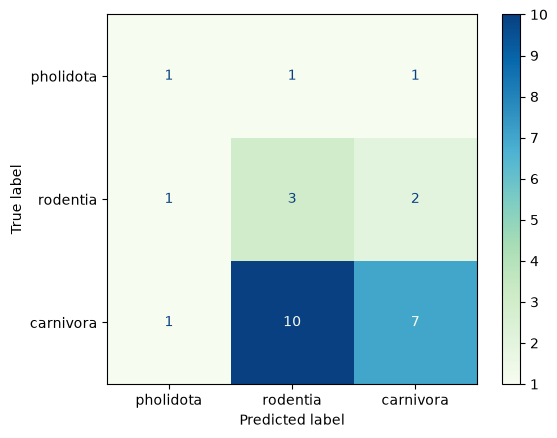

In [23]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [24]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

{'0': {'precision': 0.3333333333333333,
  'recall': 0.3333333333333333,
  'f1-score': 0.3333333333333333,
  'support': 3.0},
 '1': {'precision': 0.21428571428571427,
  'recall': 0.5,
  'f1-score': 0.3,
  'support': 6.0},
 '2': {'precision': 0.7,
  'recall': 0.3888888888888889,
  'f1-score': 0.5,
  'support': 18.0},
 'accuracy': 0.4074074074074074,
 'macro avg': {'precision': 0.4158730158730159,
  'recall': 0.4074074074074074,
  'f1-score': 0.37777777777777777,
  'support': 27.0},
 'weighted avg': {'precision': 0.5513227513227513,
  'recall': 0.4074074074074074,
  'f1-score': 0.43703703703703706,
  'support': 27.0}}

In [10]:
# precision metrics for each class (for later)
# metrics_list = [
#     tf.keras.metrics.Precision(class_id = i, name = f"precision_{int_to_order[i]}") for i in range(len(order_to_int))
# ]

In [11]:
# ML model
model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation = "softmax")
])

# compile model
model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

# fit model
model.fit(
    x = x_train,
    y = y_train,
    batch_size = 16,
    epochs = 50,
    validation_data = (x_val, y_val)
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 4.5816 - sparse_categorical_accuracy: 0.5317 - val_loss: 3.0778 - val_sparse_categorical_accuracy: 0.6667
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.7826 - sparse_categorical_accuracy: 0.6270 - val_loss: 1.1807 - val_sparse_categorical_accuracy: 0.2593
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0881 - sparse_categorical_accuracy: 0.5317 - val_loss: 1.2644 - val_sparse_categorical_accuracy: 0.6667
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.2953 - sparse_categorical_accuracy: 0.6429 - val_loss: 1.0919 - val_sparse_categorical_accuracy: 0.6296
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.0853 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.0909 - val_sparse_categorical_accuracy: 0.6296
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.0794 - sparse_categorical_accuracy: 0.6746 - val_loss: 1.0720 - val_sparse_categorical_accuracy: 0.6667
Epoch 7/50
8/8 ━━━━━━

In [12]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
(27, 3)


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

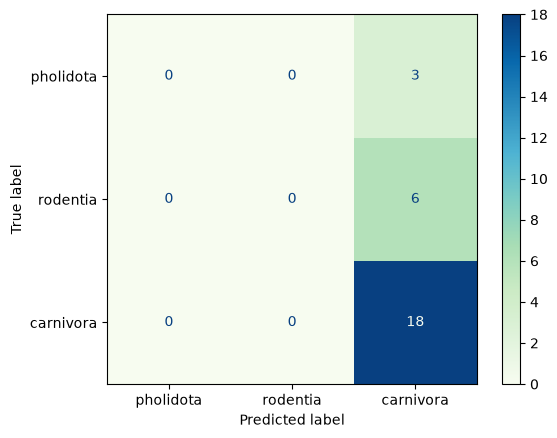

In [13]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [14]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
 '2': {'precision': 0.6666666666666666,
  'recall': 1.0,
  'f1-score': 0.8,
  'support': 18.0},
 'accuracy': 0.6666666666666666,
 'macro avg': {'precision': 0.2222222222222222,
  'recall': 0.3333333333333333,
  'f1-score': 0.26666666666666666,
  'support': 27.0},
 'weighted avg': {'precision': 0.4444444444444444,
  'recall': 0.6666666666666666,
  'f1-score': 0.5333333333333333,
  'support': 27.0}}

In [15]:
# estimate class weights (dataset is unbalanced)
data_balance = compute_class_weight(class_weight = "balanced", classes = np.unique(y_train), y = y_train)
print(data_balance)

[3.  1.5 0.5]


In [16]:
classes = np.unique(y_train)

db_results = {int(k): float(v) for k, v in zip(classes, data_balance)}
print(db_results)

{0: 3.0, 1: 1.5, 2: 0.5}


In [17]:
# new model with class weights
# ML model
weighted_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation = "softmax")
])

# compile model
weighted_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

weighted_hist = weighted_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results
                )

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 11.7815 - sparse_categorical_accuracy: 0.1508 - val_loss: 1.3975 - val_sparse_categorical_accuracy: 0.6296
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.9320 - sparse_categorical_accuracy: 0.3492 - val_loss: 1.2692 - val_sparse_categorical_accuracy: 0.2222
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.3457 - sparse_categorical_accuracy: 0.4048 - val_loss: 1.0963 - val_sparse_categorical_accuracy: 0.6296
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.0986 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.0945 - val_sparse_categorical_accuracy: 0.6667
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.0987 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.0940 - val_sparse_categorical_accuracy: 0.6667
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.0987 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.0939 - val_sparse_categorical_accuracy: 0.6667
Epoch 7/50
8/8 ━━━━━━

In [18]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = weighted_model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
(27, 3)


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

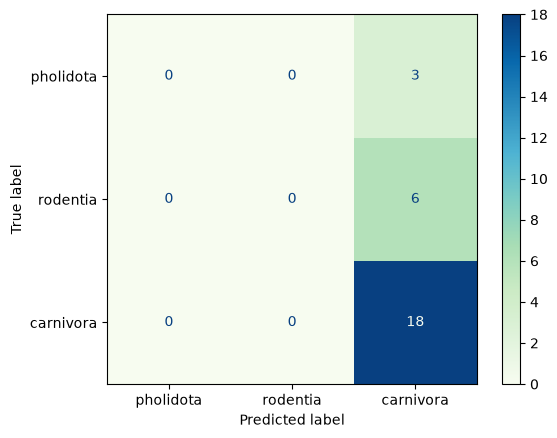

In [19]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [20]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
 '2': {'precision': 0.6666666666666666,
  'recall': 1.0,
  'f1-score': 0.8,
  'support': 18.0},
 'accuracy': 0.6666666666666666,
 'macro avg': {'precision': 0.2222222222222222,
  'recall': 0.3333333333333333,
  'f1-score': 0.26666666666666666,
  'support': 27.0},
 'weighted avg': {'precision': 0.4444444444444444,
  'recall': 0.6666666666666666,
  'f1-score': 0.5333333333333333,
  'support': 27.0}}

### Dropout has been lowered to 0.1

In [21]:
# new model but changed dropout
# ML model
low_do_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.1),
    layers.Dense(3, activation = "softmax")
])

# compile model
low_do_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

low_do_hist = low_do_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results
                )

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 11.0233 - sparse_categorical_accuracy: 0.4206 - val_loss: 11.8266 - val_sparse_categorical_accuracy: 0.1111
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 5.7733 - sparse_categorical_accuracy: 0.3730 - val_loss: 2.4557 - val_sparse_categorical_accuracy: 0.2222
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.5153 - sparse_categorical_accuracy: 0.4127 - val_loss: 2.0256 - val_sparse_categorical_accuracy: 0.3333
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.6320 - sparse_categorical_accuracy: 0.4524 - val_loss: 1.7529 - val_sparse_categorical_accuracy: 0.2963
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.5767 - sparse_categorical_accuracy: 0.5317 - val_loss: 0.9412 - val_sparse_categorical_accuracy: 0.5556
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.0019 - sparse_categorical_accuracy: 0.3651 - val_loss: 1.0767 - val_sparse_categorical_accuracy: 0.1852
Epoch 7/50
8/8 ━━━━━

In [22]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = low_do_model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
(27, 3)


array([1, 2, 2, 1, 1, 1, 2, 1, 2, 1, 0, 1, 2, 1, 1, 1, 1, 2, 2, 0, 2, 2,
       0, 1, 2, 1, 1])

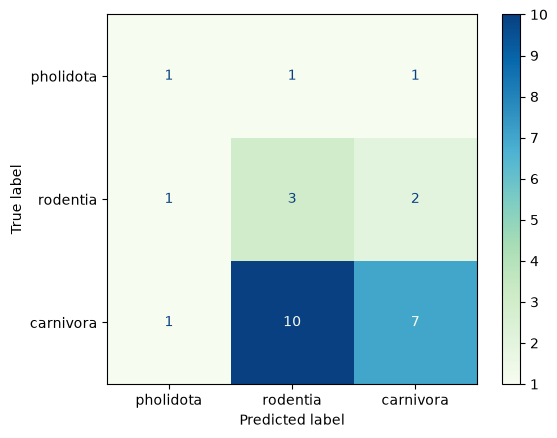

In [23]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [24]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

{'0': {'precision': 0.3333333333333333,
  'recall': 0.3333333333333333,
  'f1-score': 0.3333333333333333,
  'support': 3.0},
 '1': {'precision': 0.21428571428571427,
  'recall': 0.5,
  'f1-score': 0.3,
  'support': 6.0},
 '2': {'precision': 0.7,
  'recall': 0.3888888888888889,
  'f1-score': 0.5,
  'support': 18.0},
 'accuracy': 0.4074074074074074,
 'macro avg': {'precision': 0.4158730158730159,
  'recall': 0.4074074074074074,
  'f1-score': 0.37777777777777777,
  'support': 27.0},
 'weighted avg': {'precision': 0.5513227513227513,
  'recall': 0.4074074074074074,
  'f1-score': 0.43703703703703706,
  'support': 27.0}}

### Dropout has been increased to 0.3

In [25]:
# new model but changed dropout
# ML model
low_do_model2 = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation = "softmax")
])

# compile model
low_do_model2.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

low_do_hist2 = low_do_model2.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results
                )

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 10.7159 - sparse_categorical_accuracy: 0.4286 - val_loss: 4.1487 - val_sparse_categorical_accuracy: 0.1111
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4.8278 - sparse_categorical_accuracy: 0.2857 - val_loss: 1.4339 - val_sparse_categorical_accuracy: 0.2963
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.6370 - sparse_categorical_accuracy: 0.2540 - val_loss: 1.1015 - val_sparse_categorical_accuracy: 0.0741
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.0986 - sparse_categorical_accuracy: 0.1111 - val_loss: 1.1018 - val_sparse_categorical_accuracy: 0.0741
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.0986 - sparse_categorical_accuracy: 0.1111 - val_loss: 1.1019 - val_sparse_categorical_accuracy: 0.0741
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.0987 - sparse_categorical_accuracy: 0.1111 - val_loss: 1.1022 - val_sparse_categorical_accuracy: 0.0741
Epoch 7/50
8/8 ━━━━━━

In [26]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = low_do_model2.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
(27, 3)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0])

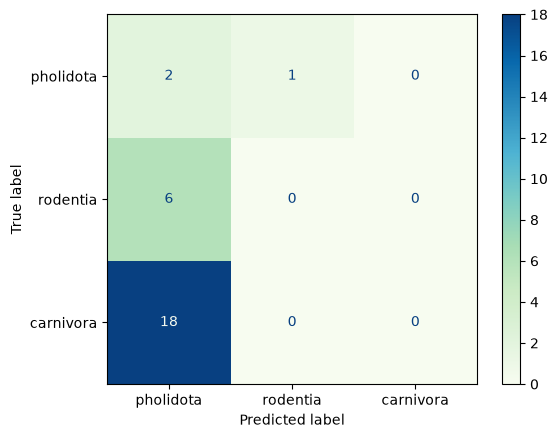

In [27]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [28]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.07692307692307693,
  'recall': 0.6666666666666666,
  'f1-score': 0.13793103448275862,
  'support': 3.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
 '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 18.0},
 'accuracy': 0.07407407407407407,
 'macro avg': {'precision': 0.025641025641025644,
  'recall': 0.2222222222222222,
  'f1-score': 0.04597701149425287,
  'support': 27.0},
 'weighted avg': {'precision': 0.008547008547008548,
  'recall': 0.07407407407407407,
  'f1-score': 0.01532567049808429,
  'support': 27.0}}

In [29]:
# finding pholidota & rodentia positions
pholidota_indices = np.where(y_train == 0)[0]
rodentia_indices = np.where(y_train == 1)[0]

print(pholidota_indices)
print(rodentia_indices)

[ 1  5 21 23 27 34 49 53 69 73 75 78 88 90]
[  9  17  22  25  26  30  33  38  47  52  54  62  67  68  71  79  82  86
  89  92  97  99 101 102 113 114 118 120]


#### To improve on the model, we will now oversample our minority classes by repeating entries, making a bigger list.

number of entries for the pholidota order: 14
number of entries for the rodentia order: 28

number of entries per minority classes to duplicate: 14

new total entries for philodota: 28 (+14)
new total entries for rodentia: 42 (+14)

In [30]:
# Numpy built-in random generator to pick 14 random samples from rodentia
rdm_gen = np.random.default_rng()
len_rodentia_choices = int(len(rodentia_indices) / 2)

rodentia_choices = rdm_gen.choice(
    rodentia_indices, 
    size = len_rodentia_choices,
    replace = False
)

print(rodentia_choices)

[ 22  99  79  92  30   9 101  67  47 114  82  25  68 102]


In [31]:
newX_train = np.concat((x_train, x_train[pholidota_indices], x_train[rodentia_choices]))
newY_train = np.concat((y_train, y_train[pholidota_indices], y_train[rodentia_choices]))

# check if new training sets are of the correct shape
print(newX_train.shape)
print(newY_train.shape)
print("Total label counts:", len(set(newY_train)))
print("Labels:", np.unique(newY_train, return_counts = True))

(154, 19200)
(154,)
Total label counts: 3
Labels: (array([0, 1, 2], dtype=int32), array([28, 42, 84]))


In [32]:
# shuffle new training set
rdm_perm = np.random.permutation(len(newX_train))
newX_train, newY_train = newX_train[rdm_perm], newY_train[rdm_perm]

# check that shuffled training set has no new values/changes
print(newX_train.shape)
print(newY_train.shape)
print("Total label counts:", len(set(newY_train)))
print("Labels:", np.unique(newY_train, return_counts = True))

(154, 19200)
(154,)
Total label counts: 3
Labels: (array([0, 1, 2], dtype=int32), array([28, 42, 84]))


In [33]:
# new model but with oversampling, dropout lowered to 0.2
# ML model
model4 = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.2),
    layers.Dense(3, activation = "softmax")
])

# compile model
model4.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

model_hist4 = model4.fit(
                    x = newX_train,
                    y = newY_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                )

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 5.0978 - sparse_categorical_accuracy: 0.4675 - val_loss: 1.7198 - val_sparse_categorical_accuracy: 0.4444
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.4408 - sparse_categorical_accuracy: 0.4026 - val_loss: 1.3548 - val_sparse_categorical_accuracy: 0.1481
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0507 - sparse_categorical_accuracy: 0.3701 - val_loss: 0.9127 - val_sparse_categorical_accuracy: 0.6667
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.9539 - sparse_categorical_accuracy: 0.5455 - val_loss: 0.9581 - val_sparse_categorical_accuracy: 0.6296
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9739 - sparse_categorical_accuracy: 0.5714 - val_loss: 0.9159 - val_sparse_categorical_accuracy: 0.6667
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9617 - sparse_categorical_accuracy: 0.5584 - val_loss: 0.9469 - val_sparse_categorical_accuracy: 0.5556
Epoch 7/50

In [34]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = model4.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
(27, 3)


array([2, 1, 2, 2, 2, 1, 1, 1, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 0, 1, 1])

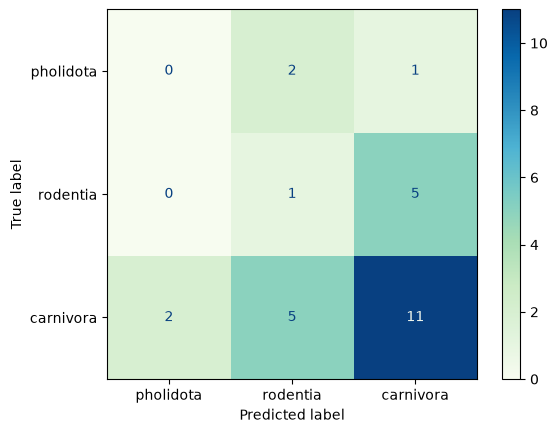

In [35]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [36]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 '1': {'precision': 0.125,
  'recall': 0.16666666666666666,
  'f1-score': 0.14285714285714285,
  'support': 6.0},
 '2': {'precision': 0.6470588235294118,
  'recall': 0.6111111111111112,
  'f1-score': 0.6285714285714286,
  'support': 18.0},
 'accuracy': 0.4444444444444444,
 'macro avg': {'precision': 0.2573529411764706,
  'recall': 0.25925925925925924,
  'f1-score': 0.2571428571428571,
  'support': 27.0},
 'weighted avg': {'precision': 0.45915032679738566,
  'recall': 0.4444444444444444,
  'f1-score': 0.45079365079365075,
  'support': 27.0}}

In [38]:
# recall low_do & low_do 2 models keys
low_do_history = low_do_hist.history
low_do_history2 = low_do_hist2.history

print(low_do_history.keys())
print(low_do_history2.keys())

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])
dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])


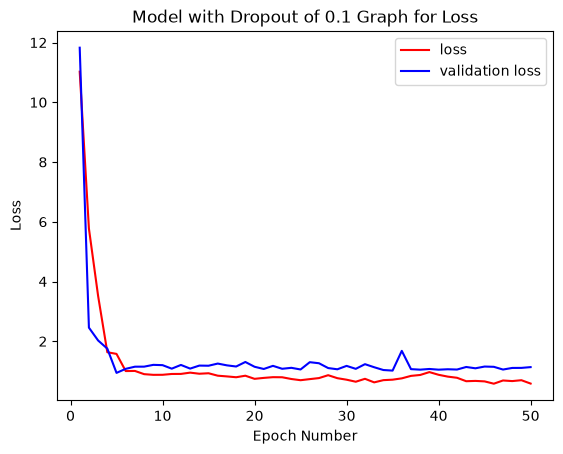

In [46]:
# overfitting graph for model with dropout of 0.1
x1 = np.arange(1, 51, 1)
y1A, y1B = low_do_history["loss"], low_do_history["val_loss"]

plt.plot(x1, y1A, color = "r", label = "loss")
plt.plot(x1, y1B, color = "b", label = "validation loss")

plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.title("Model with Dropout of 0.1 Graph for Loss")
plt.legend()
plt.show()

The model learned rapidly during the first few epochs. After approximately 5–10 epochs, training loss continued to decrease while validation loss remained relatively stable, indicating the beginning of overfitting.

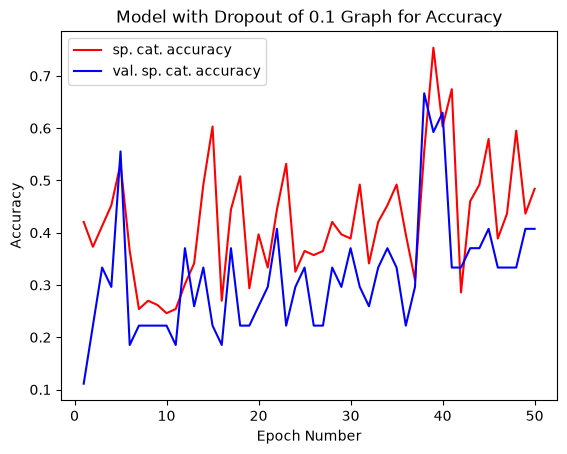

In [47]:
# overfitting graph for model with dropout of 0.1
x2 = np.arange(1, 51, 1)
y2A, y2B = low_do_history["sparse_categorical_accuracy"], low_do_history["val_sparse_categorical_accuracy"]

plt.plot(x2, y2A, color = "r", label = "sp. cat. accuracy")
plt.plot(x2, y2B, color = "b", label = "val. sp. cat. accuracy")

plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.title("Model with Dropout of 0.1 Graph for Accuracy")
plt.legend()
plt.show()

The accuracy curves were unstable because of the limited dataset size. Training accuracy generally exceeded validation accuracy, particularly in later epochs, indicating overfitting. However, both curves showed substantial fluctuations, suggesting that model performance was also sensitive to the small training and validation sample sizes.

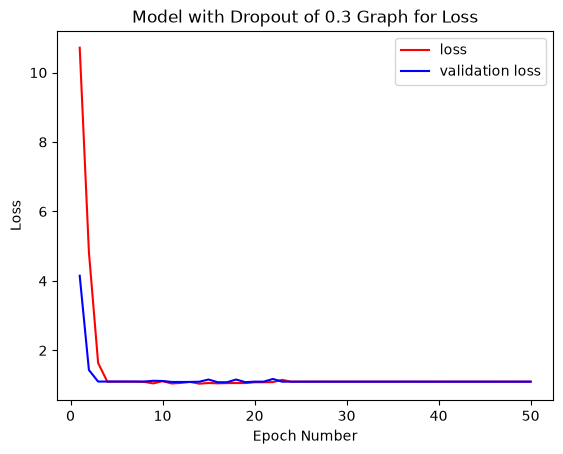

In [48]:
# overfitting graph for model with dropout of 0.3
x3 = np.arange(1, 51, 1)
y3A, y3B = low_do_history2["loss"], low_do_history2["val_loss"]

plt.plot(x3, y3A, color = "r", label = "loss")
plt.plot(x3, y3B, color = "b", label = "validation loss")

plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.title("Model with Dropout of 0.3 Graph for Loss")
plt.legend()
plt.show()

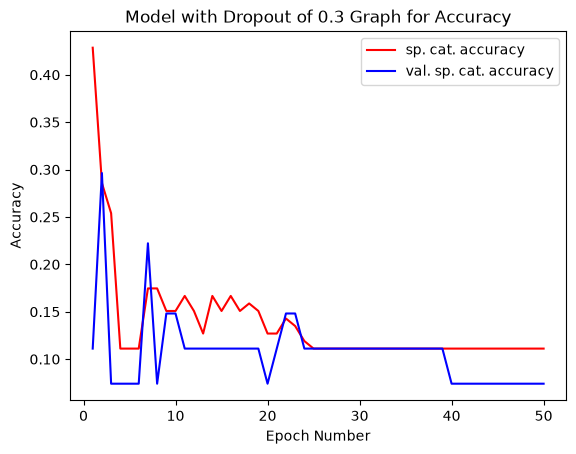

In [50]:
# overfitting graph for model with dropout of 0.3
x4 = np.arange(1, 51, 1)
y4A, y4B = low_do_history2["sparse_categorical_accuracy"], low_do_history2["val_sparse_categorical_accuracy"]

plt.plot(x4, y4A, color = "r", label = "sp. cat. accuracy")
plt.plot(x4, y4B, color = "b", label = "val. sp. cat. accuracy")

plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.title("Model with Dropout of 0.3 Graph for Accuracy")
plt.legend()
plt.show()

In [51]:
# recall model4 (oversampling minority classes) keys
m4_history = model_hist4.history

print(m4_history.keys())

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])


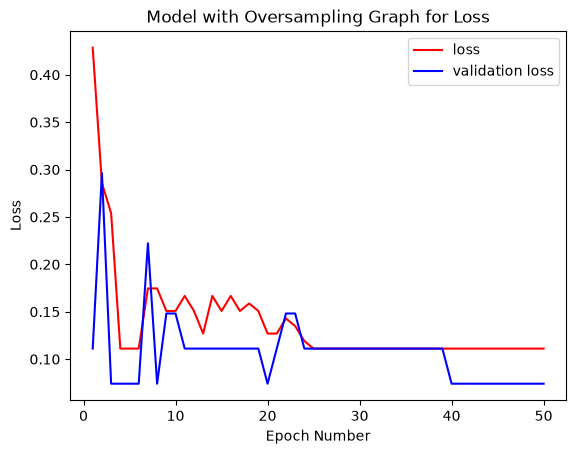

In [52]:
# overfitting graph for model with oversampling
x5 = np.arange(1, 51, 1)
y5A, y5B = m4_history["loss"], m4_history["val_loss"]

plt.plot(x4, y4A, color = "r", label = "loss")
plt.plot(x4, y4B, color = "b", label = "validation loss")

plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.title("Model with Oversampling Graph for Loss")
plt.legend()
plt.show()

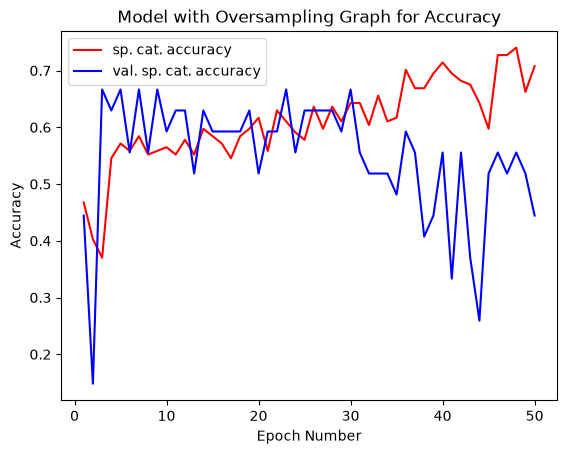

In [53]:
# overfitting graph for model with oversampling
x6 = np.arange(1, 51, 1)
y6A, y6B = m4_history["sparse_categorical_accuracy"], m4_history["val_sparse_categorical_accuracy"]

plt.plot(x6, y6A, color = "r", label = "sp. cat. accuracy")
plt.plot(x6, y6B, color = "b", label = "val. sp. cat. accuracy")

plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.title("Model with Oversampling Graph for Accuracy")
plt.legend()
plt.show()

Although partial oversampling increased fit to the training data, it did not improve generalisation to the minority classes and showed signs of overfitting. 

Thus, the best model thus far would be the model with the dropout rate of 0.1 with class weights.